In [3]:
# Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Developer\python_course_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US = df_DA_US.dropna(subset = ['salary_year_avg'])

df_DA_US['salary_year_avg'].sample(10)

461842     80000.0
637497     90000.0
731324    110000.0
458412     77338.5
332738    100700.0
144532     65000.0
320399    110000.0
768675     90000.0
183027     92750.0
701449    120000.0
Name: salary_year_avg, dtype: float64

<Axes: >

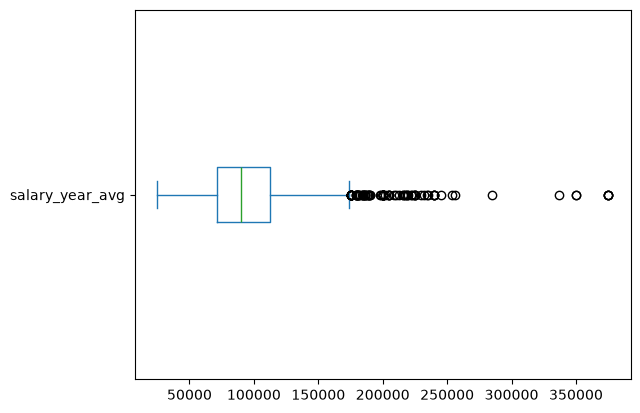

In [3]:
df_DA_US['salary_year_avg'].plot(kind = 'box', vert = False)

{'whiskers': [<matplotlib.lines.Line2D at 0x18502583090>,
 'caps': [<matplotlib.lines.Line2D at 0x18502590790>,
 'boxes': [<matplotlib.lines.Line2D at 0x184fc409190>],
 'medians': [<matplotlib.lines.Line2D at 0x18502591b50>],
 'fliers': [<matplotlib.lines.Line2D at 0x18502592550>],
 'means': []}

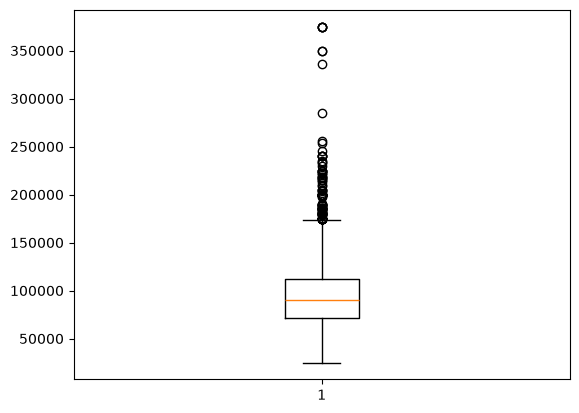

In [5]:
plt.boxplot(df_DA_US['salary_year_avg'])

C:\Users\Shivangi\AppData\Local\Temp\ipykernel_18232\2569018831.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list, tick_labels = job_titles, vert = False)


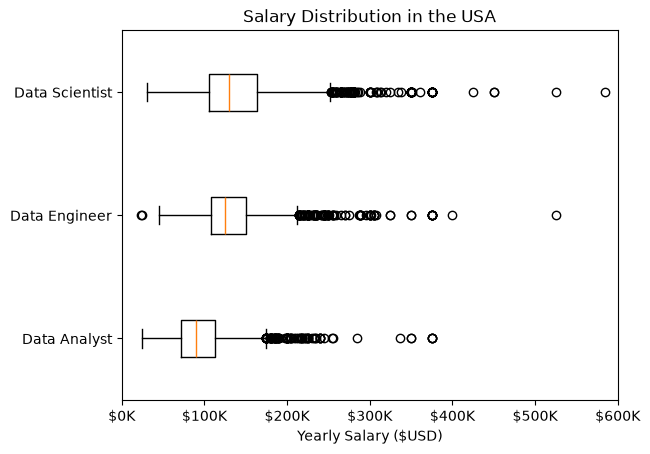

In [17]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()

df_US = df_US.dropna(subset = ['salary_year_avg'])

job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, tick_labels = job_titles, vert = False)

plt.title('Salary Distribution in the USA')
plt.xlabel('Yearly Salary ($USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 600000)
plt.show()